# Energy flow in E-M systems through Poynting vectors

The poynting vector $\vec{S} = \frac{\vec{E}\times\vec{B}}{\mu_0}$ represents the direction and rate of transfer of energy in electromagnetic fields. To illustrate this for yourself, consider a space containing an electric field $\vec{E}$ and a magnetic field $\vec{B}$ with energy density $u(x,y,z,t)$. The rate of change of the energy density at a particular location $(x_0, y_0, z_0)$ will be $(\frac{\partial u}{\partial t})_{(x_0,y_0,z_0)}$

Realize that the energy in a region of volume $V$ will reduce if it's been used to do some work. Either this **or** some energy literally left that region. In other words, $$ - \frac{\partial}{\partial t} \oint_V u dV = \frac{dW}{dt} + \oint_{A = \partial V} u\vec{v} \cdot d\vec{A}  $$

Here, the vector $u\vec{v}$ is defined as the poynting vector, $\vec{S}$, and $\vec{v}$ is the velocity of the energy flow. This turns the equation to $$ - \frac{\partial}{\partial t} \oint_V u dV = \frac{dW}{dt} + \oint_{A = \partial V} \vec{S} \cdot d\vec{A}  $$

This is so far true for any system whose energy density is being represented as $u$ as this is merely a restatement of the continuity equation. The vector $\vec{S}$ is not the poynting vector until the energy density is that of an electromagnetic field. The work done $W$ by the electromagentic field on a charge that exists in that region is $$ W = q(\vec{E} + \vec{v} \times \vec{B}) \cdot \vec{v} dt $$ $$ \frac{dW}{dt} = q(\vec{E} + \vec{v} \times \vec{B}) \cdot \vec{v} = q(\vec{E} \cdot \vec{v})$$ $$ q = \oint_V \rho dV \implies q(\vec{E} \cdot \vec{v}) = \oint_V \vec{E} \cdot \rho \vec{v} dV = \oint_V \vec{E} \cdot \vec{J} dV $$

$\vec{J}$ is the current density.

The equation is now, $$ - \frac{\partial}{\partial t} \oint_V u dV = \oint_V \vec{E} \cdot \vec{J} dV + \oint_{A = \partial V} \vec{S} \cdot d\vec{A}  $$ and we now use the divergence theorem to obtain $$ - \frac{\partial}{\partial t} \oint_V u dV = \oint_V \vec{E} \cdot \vec{J} dV + \oint_V \nabla \cdot \vec{S} dV $$ $$ \implies - \frac{\partial u}{\partial t} = \vec{E} \cdot \vec{J} + \nabla \cdot \vec{S} $$

This final equation is the **Poynting Theorem**.

## Example 1: Poynting vector field from static fields

If a magnetic dipole and an electric point charge were situated in space, they would both give out fields that didn't care about the other. This is because the magnetic field from the magnetic dipole requires a moving charge to exert a force but our charge is stationary and the electric field from the charge requires another charge but the magnetic dipole is neutral. 

The energy density of the electric field is $ u_{E} = \frac{\varepsilon_0 E^2}{2} $ and for the magnetic field, it is $u_B = \frac{B^2}{2\mu_0}$.
The total $u$ is the sum.

It seems that the time derivate of $u$ must be zero since the electric and magnetic fields here are static and do not change with time. $$ \frac{\partial u}{\partial t} = \frac{\partial}{\partial t} (\frac{\varepsilon_0 E^2}{2} + \frac{B^2}{2\mu_0}) = 0 $$ 

If the energy density at every point in space is constant through time, it is understandable to conclude that there must be no energy flow since a flow describes an increase at the sink and a decrease at a source which isn't allowed by virtue of constancy. Yet, if you took the crossproduct between the electric and magnetic field vectors, you get a non-zero $\vec{S}$. This is of course only just the trivial case and the equations are consistent. With no currents in this system, the poynting theorem gives us $$ - \frac{\partial u}{\partial t} = \nabla \cdot \vec{S} = 0 $$ It is therefore clear that, in our static field case, it is the divergence that needs to be zero and not the poynting vector. (after all, if what leaves is immediately replenished by another source, it is in all sense constant)

What we know about $\vec{S}$ so far is that it must be solenoidal. We can check this by taking the cross  product of the $\vec{E}$ - field and $\vec{B}$ - field vectors at each point and look at the resulting vector field. A computer program is used to do that for us.

#### Set-up

- A Magnetic dipole of $(0,0,m)$ at $(0,0,0)$ $$ \vec{B} = \frac{\mu_0}{4\pi} \frac{3(\vec{m}\cdot \hat{r})(\hat{r} - \vec{m})}{r^3} $$
- point charge $q$ at $(0,0,0)$ $$ \vec{E} = \frac{1}{4\pi\varepsilon_0} \frac{q}{r^2} \hat{r} $$
- the poynting vector(at least the direction) is then $\vec{E} \times \vec{B}$

In [2]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

epsilon_0 = 8.854*10**-12  #permittivity of free space
mu_0 = 4*np.pi*10**-7  #permeability of free space
q = 1  #charge
m = 1  #magnetic moment
x0, y0 = 0, 0  #dipole

x, y, z = sp.symbols('x y z')    

#position vector
r_vector = sp.Matrix([x - x0, y - y0, 0])  
r_magnitude = r_vector.norm()

#E-field from point charge
E_vector = (1/(4*sp.pi*epsilon_0))*(q / r_magnitude**3)*r_vector

#Mag-field from dipole (XY)
m_vector = sp.Matrix([0, 0, m])  
r_hat = r_vector / r_magnitude  
B_vector_xy = (mu_0 / (4 * sp.pi))*(1 / r_magnitude**3)*(3*(m_vector.dot(r_hat))*r_hat - m_vector)

#XZ
r_vector_xz = sp.Matrix([x - x0, 0, z - y0])  
r_magnitude_xz = r_vector_xz.norm()
r_hat_xz = r_vector_xz/r_magnitude_xz  
B_vector_xz = (mu_0/(4 * sp.pi))*(1/r_magnitude_xz**3)*(3*(m_vector.dot(r_hat_xz))*r_hat_xz - m_vector)

#poynting vector
S_vector = E_vector.cross(B_vector_xy)

The following shows the plot of all the fields, normalized.

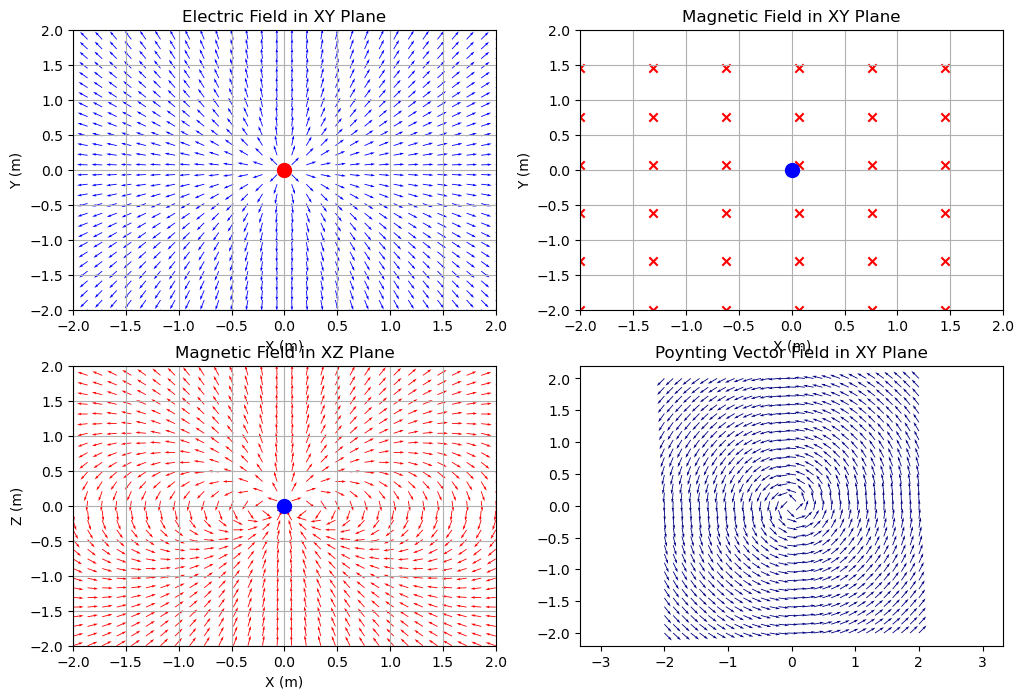

In [3]:
#here we define a function to normalize so the plot looks neat. 
#we only care about direction
def normalize(vector):
    return vector/(vector.norm() + 1e-12)  

E_unit = normalize(E_vector)
B_unit_xy = normalize(B_vector_xy)
B_unit_xz = normalize(B_vector_xz)
S_unit = normalize(S_vector)

E_x = sp.lambdify((x, y), E_unit[0], 'numpy')
E_y = sp.lambdify((x, y), E_unit[1], 'numpy')
B_x = sp.lambdify((x, y), B_unit_xy[0], 'numpy')
B_y = sp.lambdify((x, y), B_unit_xy[1], 'numpy')
B_z = sp.lambdify((x, y), B_unit_xy[2], 'numpy')
B_x_xz = sp.lambdify((x, z), B_unit_xz[0], 'numpy')
B_z_xz = sp.lambdify((x, z), B_unit_xz[2], 'numpy')
Sx = sp.lambdify((x, y), S_unit[0], 'numpy')
Sy = sp.lambdify((x, y), S_unit[1], 'numpy')

x_vals = np.linspace(-2, 2, 30)
y_vals = np.linspace(-2, 2, 30)
z_vals = np.linspace(-2, 2, 30)
X, Y = np.meshgrid(x_vals, y_vals)
X_xz, Z_xz = np.meshgrid(x_vals, z_vals)

Ex = E_x(X, Y)
Ey = E_y(X, Y)
Bx = B_x(X, Y)
By = B_y(X, Y)
Bz = B_z(X,Y)
Bx_xz_vals = B_x_xz(X_xz, Z_xz)
Bz_xz_vals = B_z_xz(X_xz, Z_xz)
Sx_vals = Sx(X, Y)
Sy_vals = Sy(X, Y)

sample_step = 5
sample_X = X[::sample_step, ::sample_step]
sample_Y = Y[::sample_step, ::sample_step]
sample_B_z = Bz[::sample_step, ::sample_step]

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.quiver(X, Y, Ex, Ey, scale=40, color='b', width= 0.002)
plt.scatter(x0, y0, color='r', s=100, zorder=5)
plt.title('Electric Field in XY Plane')
plt.xlabel('X (m)')
plt.ylabel('Y (m)')
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.grid(True)

plt.subplot(2, 2, 2)
for i in range(sample_X.shape[0]):
    for j in range(sample_X.shape[1]):
        if sample_B_z[i, j] > 0:
            plt.scatter(sample_X[i, j], sample_Y[i, j], color='red', marker='o', label='B out of plane' if i == 0 and j == 0 else "")
        elif sample_B_z[i, j] < 0:
            plt.scatter(sample_X[i, j], sample_Y[i, j], color='red', marker='x', label='B into plane' if i == 0 and j == 0 else "")
plt.title("Magnetic Field in XY plane")
plt.scatter(x0, y0, color='b', s=100, zorder=5)
plt.title('Magnetic Field in XY Plane')
plt.xlabel('X (m)')
plt.ylabel('Y (m)')
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.grid(True)

plt.subplot(2, 2, 3)
plt.quiver(X_xz, Z_xz, Bx_xz_vals, Bz_xz_vals, scale=40, color='r', width=0.002)
plt.scatter(x0, y0, color='b', s=100, zorder=5)
plt.title('Magnetic Field in XZ Plane')
plt.xlabel('X (m)')
plt.ylabel('Z (m)')
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.grid(True)

plt.subplot(2, 2, 4)
plt.quiver(X, Y, Sx_vals, Sy_vals, scale=40, color='navy', width=0.002)  # Smaller arrows
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.axis('equal')
plt.grid(False)
plt.title("Poynting Vector Field in XY Plane")
plt.show()

print()

This is an interesting result as while there is no energy flow in space there seems to be a circulation in the field. This becomes clearer when one considers that the momentum density of a field is also given by the poynting vector: $$ \vec{p} = \frac{\vec{S}}{c^2} $$ 

Considering that $\vec{r} \times \frac{\vec{S}}{c^2}$ is just the angular momentum density $\vec{J}$, we can use the identity $$\vec{r} \cdot (\nabla \times \vec{S}) = - \nabla \cdot (\vec{r} \times \vec{S})$$ and see that $$\vec{r} \cdot (\nabla \times \vec{S}) = - c^2 \nabla \cdot \vec{J}$$

This means that the poynting vector field keeps a circulation as its method of storing angular momentum that can be taken out for later use. To illustrate, consider Feynman's disc paradox from the image below (courtesy of the Feynman Lectures on Physics Vol II. Chapter 17-4, Fig. 17-5)

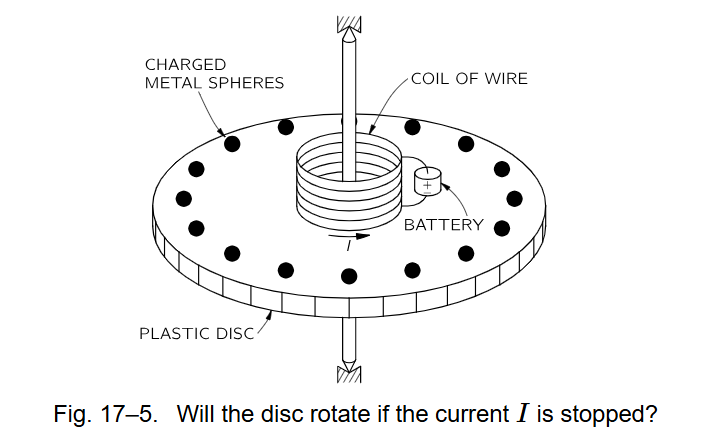

Current $I$ flows through the solenoid which sets up a magnetic field through the solenoid and around it. There are charges all around the circumference of the plastic disc. When you shut the solenoid off, the drop in the magnetic field induces a circulating electric field through Faraday's law that pushes the charges fixed on the disc causing the disc to rotate. The paradox here is as follows: if these torques are internal, where did the disc get its angular momentum from?

Of course, it's not so much of a paradox anymore since we know the electric field of the charges when crossed with magnetic field from the solenoid gives us a circulating poynting vector field which holds the angular momentum. The angular momentum is then taken out and provided to the disc when the solenoid is turned off.

## Example 2: Poynting vector field of a closed circuit

This is another famous example of the poynting vector field that we will try to visualize. It is true that in a circuit, the flow of current is due to the flow of electrons through them. It is also true that we take advantage of circuits through their resistance (light bulbs glow due to the heat generated) and resistance in a circuit is due to the collisions of the electrons with the positive cores of the conductor. During steady state, we can ignore whatever gets the circuit started but there are misconceptions regarding it.

- **the electrons leave the battery at drift velocity and reach the bulb which makes it glow**
  
  The drift velocity of an electron in a wire is roughly $~10^{-5}$ m/s. For a circuit that separates the bulb and the battery by a 1m wire, it takes $~10^5$ seconds for the electrons to reach the bulb to the battery. That is roughly a day! Yet from daily experience, you know that the bulb turns on instantly. Infact it is very surprising that you could leave a circuit on for a few hours and the electron that was near the battery is still nowhere near the bulb!

- **then it must be that the electrons repel each other and that provides the force necessary for those near the bulb to move**

    Can't. Each electron residing in the conductor effectively sees a neutral region since there are just as many positive cores as there are neighbouring electrons.

- **the battery creates an electric field that pushes the electrons near the bulb**

  Partially true. There is an electric field that's pushing the electrons in the circuit. However this electric field doesn't come from the battery. If it did, moving the bulb closer to the battery would make it glow brighter since the electric field would be stronger closer to its source. Instead the electric field exists completely inside and along the wires curving whenever the wire curves.

The true reason is that when you connect a battery to the wires and keep them disconnected, **surface charges** are set up to cancel the electric field due the battery inside the wires because they are conductors and must not have electric fields inside them under electrostatic conditions. The positive terminal of the battery creates negative surface charges on the wire connected to it and vice versa. When you join the wires, the positive charges on the face of one wire neutralises the negative charges on the face of the other and an electric field is created from the remaining surface charges. This time an electric field is allowed in the wires since a path has been created for a redox reaction to occur(if we're using a voltaic cell) which means we have left electrostatic conditions. The images below(courtesy of Chabay and Sherwood's Matter and Interactions) explains it.

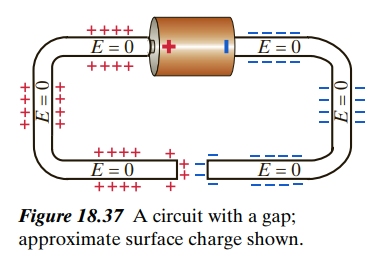 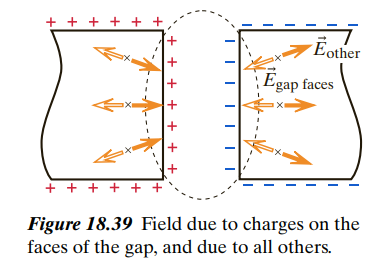 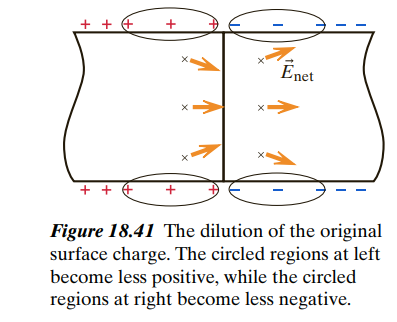 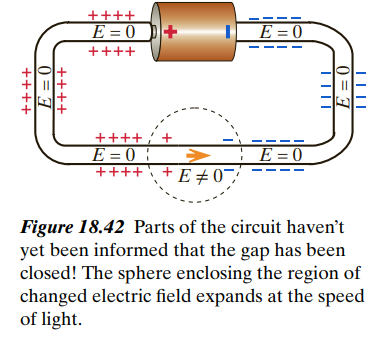

The last figure points out a noteworthy fact. This means that if you have a circuit with a light bulb near the gap of the open circuit and a light bulb near the battery separated at least a lightsecond away, you will be able to see with your eyes that closing the gap will counterintuitively first make the bulb near the gap glow and then the bulb close to the battery.

The energy you might think flows from the battery to the bulb through the wires too but that is not true. We can use a similar poynting vector field analysis to see how the energy flows in a circuit.

#### Set up

- a dipole to pretend as a battery
- a square circuit made of wires with surface charge density decreasing linearly from positve $\lambda$ to $-\lambda$ (as suggested by Chabay and Sherwood)
- We compute the magnetic fields and electric fields from the circuit and take the cross product to obtain the poynting vector field

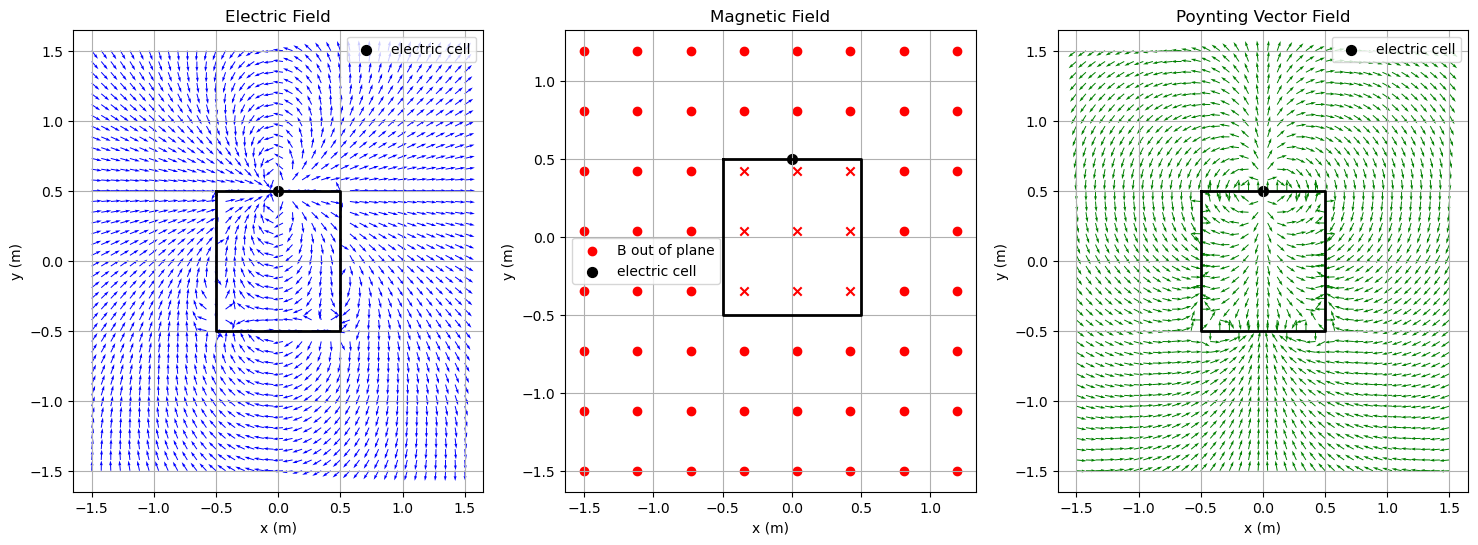

In [4]:
import numpy as np
import matplotlib.pyplot as plt

#parameters of the circuit
L = 1.0  #side length of the square circuit
lambda_0 = 0.1  #considering a linear charge variation, value at start pos.
epsilon_0 = 8.85e-12  #permittivity of free space
dipole_p = np.array([1,0])  #dipole to pretend as battery
mu_0 = 4 * np.pi * 1e-7  #permeability of free space
I = 1.0  #current in the wire

def electric_field_line_segment(start, end, lambda_start, lambda_end, grid_x, grid_y):
    E_x, E_y = np.zeros_like(grid_x), np.zeros_like(grid_y)
    num_points = 200  #number of discrete chunks field is computed for
    
    x_vals = np.linspace(start[0], end[0], num_points)
    y_vals = np.linspace(start[1], end[1], num_points)
    lambda_vals = np.linspace(lambda_start, lambda_end, num_points)
    dl = np.sqrt((x_vals[1] - x_vals[0])**2 + (y_vals[1] - y_vals[0])**2)
    
    for i in range(num_points):
        x_q, y_q, lambda_q = x_vals[i], y_vals[i], lambda_vals[i]
        dq = lambda_q*dl
        
        rx = grid_x - x_q
        ry = grid_y - y_q
        r = np.sqrt(rx**2 + ry**2)
        r[r < 1e-6] = 1e-6  
        
        dE = (dq/(4*np.pi*epsilon_0*r**3))
        E_x = E_x + dE*rx
        E_y = E_y + dE*ry
    
    return E_x, E_y

def dipole_field(px, py, grid_x, grid_y):
    p = dipole_p
    rx = grid_x - px
    ry = grid_y - py
    r = np.sqrt(rx**2 + ry**2)
    r[r < 1e-6] = 1e-6  
    
    dot_pr = p[0]*rx + p[1]*ry
    k = (1/(4*np.pi*epsilon_0*r**5))
    
    E_x = k*(3*dot_pr*rx - p[0]*r**2)
    E_y = k*(3*dot_pr*ry - p[1]*r**2)
    
    return E_x, E_y

def magnetic_field_wire_segment(start, end, grid_x, grid_y):
    B_z = np.zeros_like(grid_x)
    num_points = 200
    
    x_vals = np.linspace(start[0], end[0], num_points)
    y_vals = np.linspace(start[1], end[1], num_points)
    dl_x = np.gradient(x_vals)
    dl_y = np.gradient(y_vals)
    
    for i in range(num_points):
        x_q, y_q = x_vals[i], y_vals[i]
        dl = np.array([dl_x[i], dl_y[i]])
        
        rx = grid_x - x_q
        ry = grid_y - y_q
        r = np.sqrt(rx**2 + ry**2)
        r[r < 1e-6] = 1e-6  
        
        dB_z = (mu_0*I/(4*np.pi*r**3))*(dl[0]*ry - dl[1]*rx)
        B_z = B_z + dB_z
    
    return B_z


x = np.linspace(-1.5, 1.5, 40)
y = np.linspace(-1.5, 1.5, 40)
X, Y = np.meshgrid(x, y)

E_total_x, E_total_y = np.zeros_like(X), np.zeros_like(Y)
B_total_z = np.zeros_like(X)

top_left, top_right = (-L/2, L/2), (L/2, L/2)
bottom_left, bottom_right = (-L/2, -L/2), (L/2, -L/2)

for (start, end) in [(top_left, top_right), (top_right, bottom_right),
                     (bottom_right, bottom_left), (bottom_left, top_left)]:
    E_x, E_y = electric_field_line_segment(start, end, lambda_0, -lambda_0, X, Y)
    B_z = magnetic_field_wire_segment(start, end, X, Y)
    E_total_x = E_total_x + E_x
    E_total_y = E_total_y + E_y
    B_total_z = B_total_z + B_z

E_dx, E_dy = dipole_field(0, L/2, X, Y)
E_total_x = E_total_x + E_dx
E_total_y = E_total_y + E_dy

def normalize_vectors(Vx, Vy):
    magnitude = np.sqrt(Vx**2 + Vy**2)
    magnitude[magnitude < 1e-9] = 1e-9
    return Vx/magnitude, Vy/magnitude


#poynting vector
S_x = E_total_y*B_total_z
S_y = -E_total_x*B_total_z

E_total_x, E_total_y = normalize_vectors(E_total_x, E_total_y)
S_x, S_y = normalize_vectors(S_x, S_y)

sample_step = 5
sample_X = X[::sample_step, ::sample_step]
sample_Y = Y[::sample_step, ::sample_step]
sample_B_z = B_total_z[::sample_step, ::sample_step]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].quiver(X, Y, E_total_x, E_total_y, color='blue', scale=40)
axes[0].set_title("Electric Field")

for i in range(sample_X.shape[0]):
    for j in range(sample_X.shape[1]):
        if sample_B_z[i, j] > 0:
            axes[1].scatter(sample_X[i, j], sample_Y[i, j], color='red', marker='o', label='B out of plane' if i == 0 and j == 0 else "")
        elif sample_B_z[i, j] < 0:
            axes[1].scatter(sample_X[i, j], sample_Y[i, j], color='red', marker='x', label='B into plane' if i == 0 and j == 0 else "")
axes[1].set_title("Magnetic Field")

axes[2].quiver(X, Y, S_x, S_y, color='green', scale=40)
axes[2].set_title("Poynting Vector Field")

for ax in axes:
    ax.plot([-L/2, L/2, L/2, -L/2, -L/2], [L/2, L/2, -L/2, -L/2, L/2], 'k-', linewidth=2)
    ax.scatter(0, L/2, color='black', marker='o', s=50, label='electric cell')
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.legend()
    ax.grid()

plt.show()

The poynting vector field leaves the source and enters into each wire. It is this energy that is recieved by the wire that is converted to the kinetic energy of the electrons and then to heat. To see this consider a section of the wire.

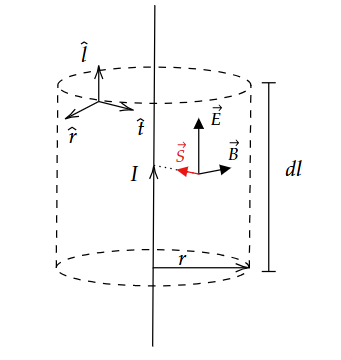

- The electric field from the wire is $\vec{E} = \frac{V}{dl} \hat{l}$
- The magentic field from the wire a distance R away is $\vec{B} = \frac{\mu_0 I}{2 \pi r} \hat{t}$

The poynting vector $\vec{S} = \frac{\vec{E} \times \vec{B}}{\mu_0}$ is then equal to $- \frac{VI}{2 \pi r dl} \hat{r}$

$$ \vec{S} = - \frac{VI}{2 \pi r dl} \hat{r}$$

since $VI$ for the resistive circuit is equal to $I^2R$, $$ \vec{S} = - \frac{I^2 R}{2 \pi r dl} \hat{r}$$

If $U$ is the energy present inside the region enclosed by the dotted cylinder, $$\frac{\partial U}{\partial t} \Delta t = - (\oint_{cylinder} \vec{S} \cdot d\vec{A}) \Delta t $$ 
$$\frac{\partial U}{\partial t} \Delta t = - (\oint_{cylinder} - (\frac{I^2 R}{2 \pi r dl} \hat{r}) \cdot d\vec{A}) \Delta t $$ 

Since the poynting vector is normal to the surface of the cylinder, the integral evaluates to give

$$\frac{\partial U}{\partial t} \Delta t = \frac{I^2 R}{2 \pi r dl} (2 \pi r dl) \Delta t $$ 

giving $$\frac{\partial U}{\partial t} \Delta t = I^2 R \Delta t $$ which we all know as the heat generated by the circuit over a time interval of $\Delta t$